# Análisis alertas (Histórico)

In [11]:
!pip install minio

   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ----------------------- ---------------- 1.0/1.8 MB 5.6 MB/s eta 0:00:01
   ---------------------------------------- 1.8/1.8 MB 5.5 MB/s eta 0:00:00


In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math
import numpy as np
from pathlib import Path
import sys, os

In [21]:
import sys
from pathlib import Path
import os
import pandas as pd

# 🔹 Añadir raíz del proyecto
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.common.minio_client import download_df_parquet

# 🔹 Credenciales
access_key = os.getenv("MINIO_ACCESS_KEY")
secret_key = os.getenv("MINIO_SECRET_KEY")

if not access_key or not secret_key:
    raise ValueError("MINIO_ACCESS_KEY y MINIO_SECRET_KEY no están definidas")

BASE_PATH = "grupo5/cleaned/official_alerts"

# 🔹 Generar todo 2025
all_days = pd.date_range("2025-01-01", "2025-12-31", freq="D")

lista_dfs = []

for day in all_days:
    day_str = day.strftime("%Y-%m-%d")
    ruta_archivo = f"{BASE_PATH}/date={day_str}/alerts.parquet"
    
    try:
        df_dia = download_df_parquet(access_key, secret_key, ruta_archivo)
        
        if not df_dia.empty:
            lista_dfs.append(df_dia)
            
    except Exception:
        # Día sin alerts.parquet
        continue

if lista_dfs:
    df_alertas = pd.concat(lista_dfs, ignore_index=True)
else:
    df_alertas = pd.DataFrame()

df_alertas.shape

(43883, 8)

In [22]:
df_alertas

,event_id,timestamp_start,timestamp_end,category,lines,text_snippet,description,num_updates
0,184983,2025-01-01 00:17:00,2025-01-01 00:17:00,Delay,J,Jamaica Center-Parsons/Archer-bound J trains a...,None,0
1,184997,2025-01-01 00:45:00,2025-01-01 00:45:00,Delay,6,Northbound 6 trains are running with delays af...,None,0
2,184998,2025-01-01 00:57:00,2025-01-01 00:57:00,Delay,"2, 3",Northbound 2/3 trains are delayed while EMS re...,None,0
3,185000,2025-01-01 01:02:00,2025-01-01 01:02:00,Delay,1,Southbound 1 trains are delayed while we remov...,None,0
4,184998,2025-01-01 01:08:00,2025-01-01 01:08:00,Delay,"2, 3",Northbound 2/3 trains are running with delays ...,None,0
...,...,...,...,...,...,...,...,...
43878,231780,2025-12-30 23:15:00,2025-12-30 23:15:00,Delay,1,Uptown 1 trains are delayed while we remove a ...,None,0
43879,231781,2025-12-30 23:18:00,2025-12-30 23:18:00,Delay,"M, R",Downtown M/R trains are delayed while we reque...,None,0
43880,231781,2025-12-30 23:19:00,2025-12-30 23:19:00,Delay,"M, R",Downtown M/R trains are running with delays af...,None,0
43881,231777,2025-12-30 23:20:00,2025-12-30 23:20:00,Delay,6,Uptown 6X trains are running with delays after...,Uptown 6X trains have resumed express service ...,0


In [27]:
cols = ["category", "lines", "description", "num_updates", "text_snippet"]

null_stats = pd.DataFrame({
    "nulos": df_alertas[cols].isnull().sum(),
    "porcentaje_nulos": df_alertas[cols].isnull().mean() * 100
})

null_stats

,nulos,porcentaje_nulos
category,0,0.000000
lines,0,0.000000
description,29091,66.292186
num_updates,0,0.000000
text_snippet,0,0.000000


Borramos la columna description , no aporta información relevante y en su 66% son nulos

In [30]:
df_alertas = df_alertas.drop(columns=["description"])

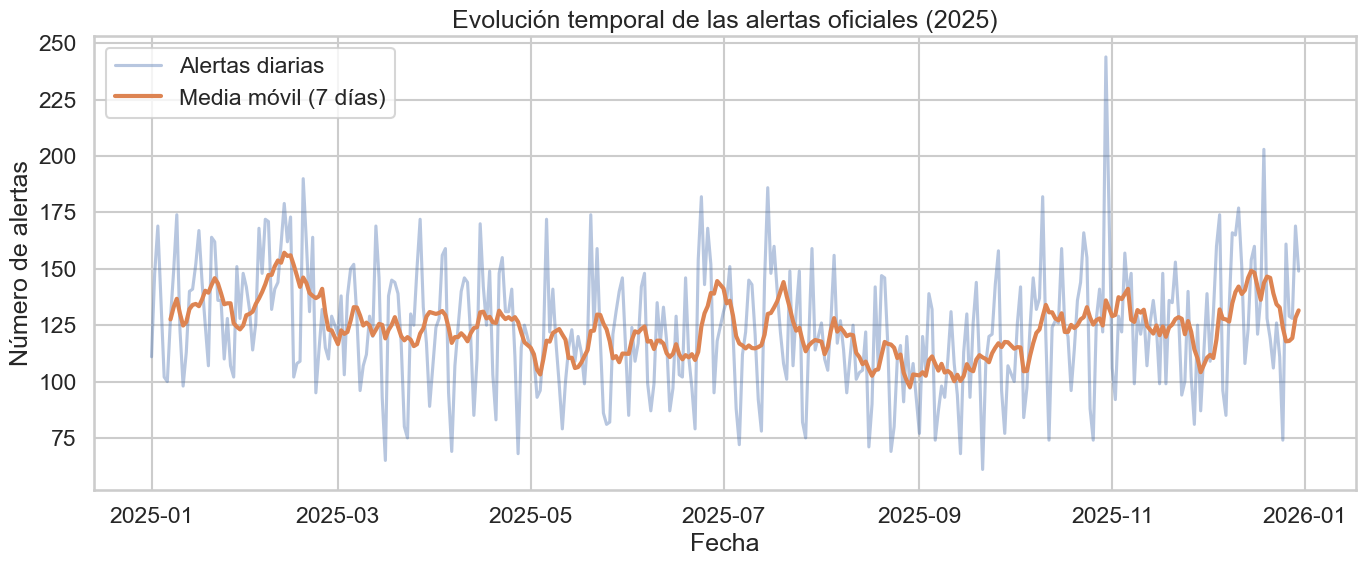

In [32]:

sns.set(style="whitegrid", context="talk")

daily_alerts = (
    df_alertas
    .groupby(df_alertas["timestamp_start"].dt.date)
    .size()
)

rolling_mean = daily_alerts.rolling(7).mean()

plt.figure(figsize=(14,6))
plt.plot(daily_alerts.index, daily_alerts.values, alpha=0.4, label="Alertas diarias")
plt.plot(rolling_mean.index, rolling_mean.values, linewidth=3, label="Media móvil (7 días)")

plt.title("Evolución temporal de las alertas oficiales (2025)")
plt.xlabel("Fecha")
plt.ylabel("Número de alertas")
plt.legend()
plt.tight_layout()
plt.show()

## Alertas por hora con línea de media

C:\Users\david\AppData\Local\Temp\ipykernel_10676\1925870791.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=alerts_by_hour.index, y=alerts_by_hour.values, palette="viridis")
C:\Users\david\AppData\Local\Temp\ipykernel_10676\1925870791.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


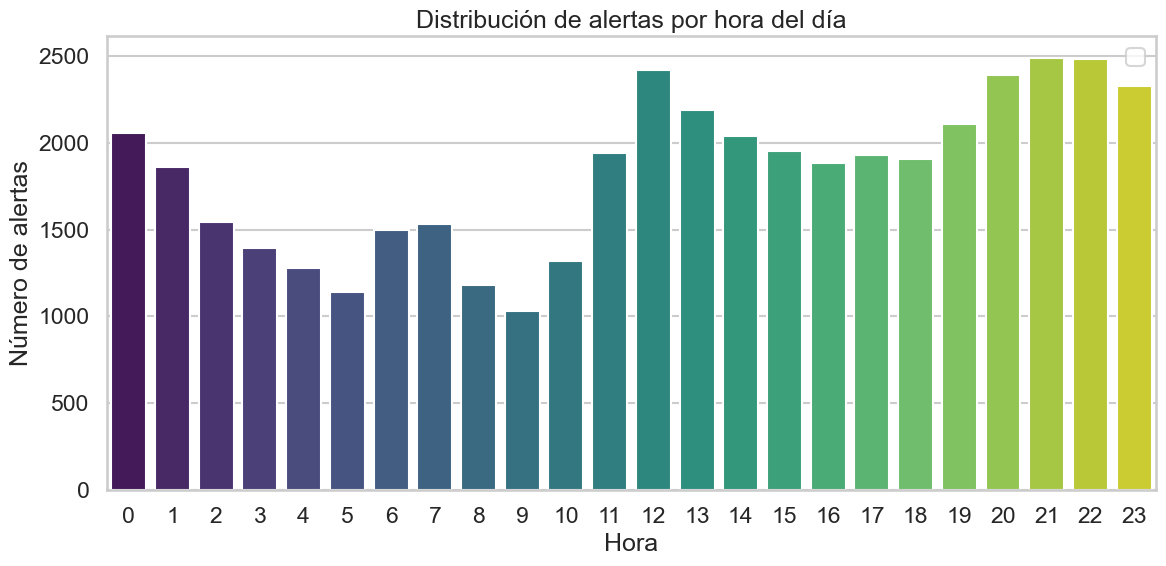

In [37]:
df_alertas["hour"] = df_alertas["timestamp_start"].dt.hour
alerts_by_hour = df_alertas.groupby("hour").size()

plt.figure(figsize=(12,6))
sns.barplot(x=alerts_by_hour.index, y=alerts_by_hour.values, palette="viridis")


plt.title("Distribución de alertas por hora del día")
plt.xlabel("Hora")
plt.ylabel("Número de alertas")
plt.legend()
plt.tight_layout()
plt.show()

## Alertas por día de la semana

C:\Users\david\AppData\Local\Temp\ipykernel_10676\574550541.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=weekday_counts.index, y=weekday_counts.values, palette="magma")


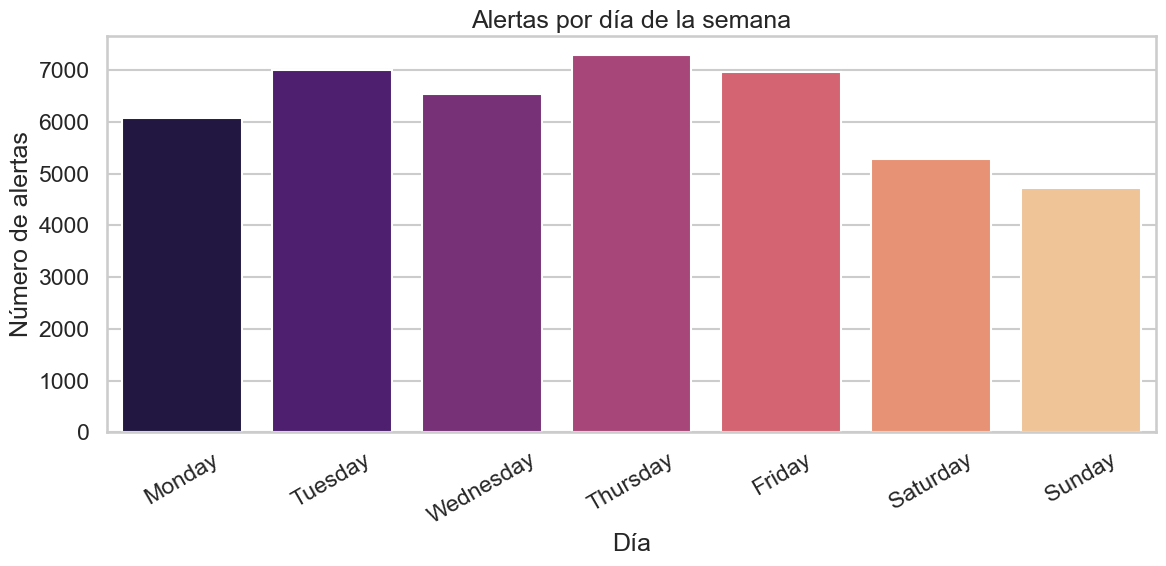

In [52]:
df_alertas["weekday"] = df_alertas["timestamp_start"].dt.day_name()

order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

weekday_counts = (
    df_alertas
    .groupby("weekday")
    .size()
    .reindex(order)
)

plt.figure(figsize=(12,6))
sns.barplot(x=weekday_counts.index, y=weekday_counts.values, palette="magma")

plt.title("Alertas por día de la semana")
plt.xlabel("Día")
plt.ylabel("Número de alertas")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [54]:
weekday_percent = (weekday_counts / weekday_counts.sum()) * 100

weekday_percent

weekday
Monday       13.843630
Tuesday      15.956065
Wednesday    14.926053
Thursday     16.614634
Friday       15.855798
Saturday     12.031994
Sunday       10.771825
dtype: float64

## Distribución por categoría con porcentaje visible

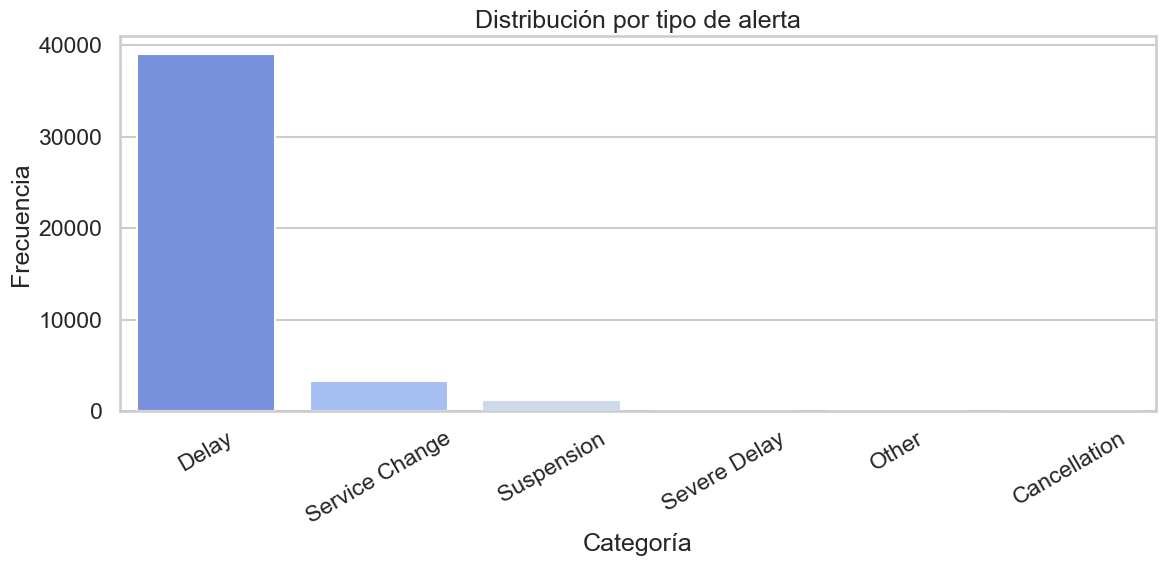

In [61]:
import pandas as pd

category_df = category_counts.reset_index()
category_df.columns = ["category", "count"]

plt.figure(figsize=(12,6))
ax = sns.barplot(
    data=category_df,
    x="category",
    y="count",
    hue="category",
    palette="coolwarm",
    legend=False
)

plt.title("Distribución por tipo de alerta")
plt.xlabel("Categoría")
plt.ylabel("Frecuencia")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [59]:
df_alertas["category"].value_counts()

category
Delay             39034
Service Change     3284
Suspension         1212
Severe Delay        209
Other                87
Cancellation         57
Name: count, dtype: int64

## Líneas más afectadas

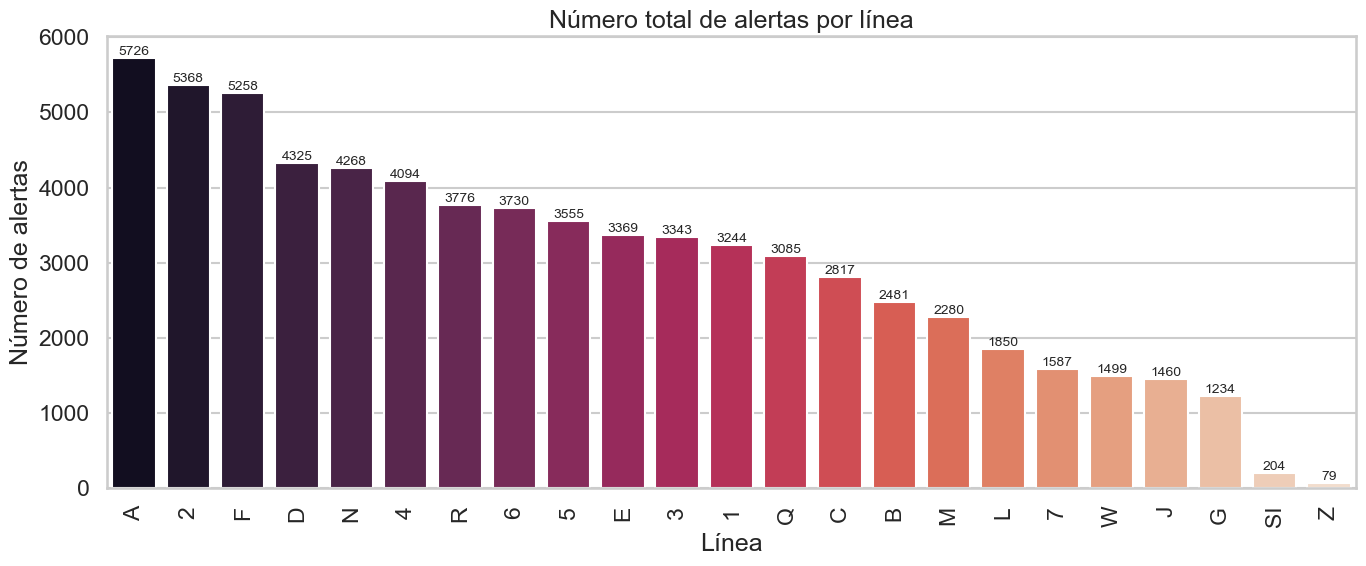

In [78]:
import seaborn as sns
import matplotlib.pyplot as plt

metro_valid_lines = [
    "1","2","3","4","5","6","7",
    "A","B","C","D","E","F","G",
    "J","L","M","N","Q","R","W",
    "Z","SI"
]

sns.set(style="whitegrid", context="talk")

df_lines = (
    df_alertas
    .assign(lines=df_alertas["lines"].str.split(", "))
    .explode("lines")
)
df_lines = df_lines[df_lines["lines"].isin(metro_valid_lines)]
#Durante el análisis se detectaron valores no pertenecientes al sistema de metro (SIM7, FX, 7X),
#Se aplicó un filtrado para restringir el análisis exclusivamente a líneas oficiales del metro.
line_counts = (
    df_lines["lines"]
    .value_counts()
    .sort_values(ascending=False)
)

line_df = line_counts.reset_index()
line_df.columns = ["line", "count"]
plt.figure(figsize=(14,6))

ax = sns.barplot(
    data=line_df,
    x="line",
    y="count",
    hue="line",      
    palette="rocket",
    legend=False
)
for i, v in enumerate(line_df["count"]):
    ax.text(i, v, str(v), ha="center", va="bottom", fontsize=10)

plt.title("Número total de alertas por línea")
plt.xlabel("Línea")
plt.ylabel("Número de alertas")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

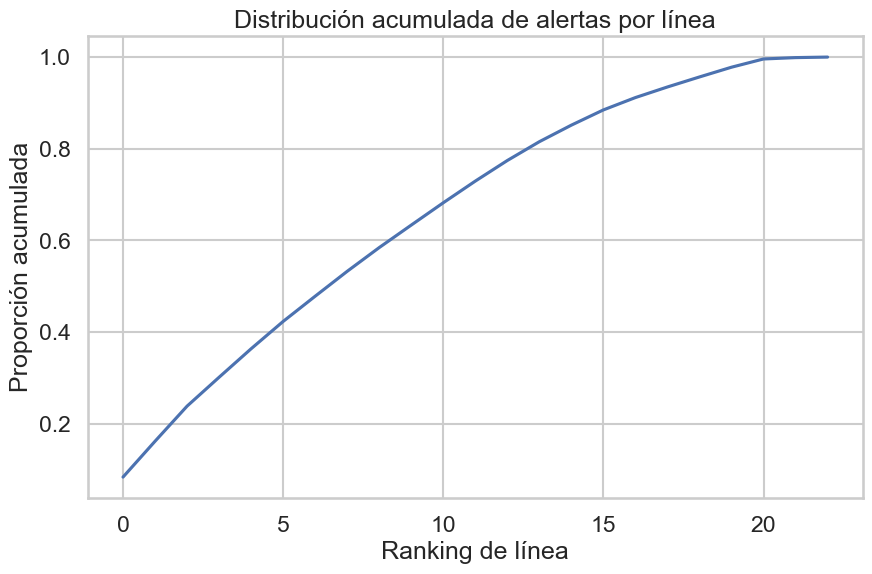

In [80]:
line_counts = df_lines["lines"].value_counts().sort_values(ascending=False)

cumulative = line_counts.cumsum() / line_counts.sum()

plt.figure(figsize=(10,6))
plt.plot(cumulative.values)
plt.title("Distribución acumulada de alertas por línea")
plt.xlabel("Ranking de línea")
plt.ylabel("Proporción acumulada")
plt.grid(True)
plt.show()

## Distribución mensual

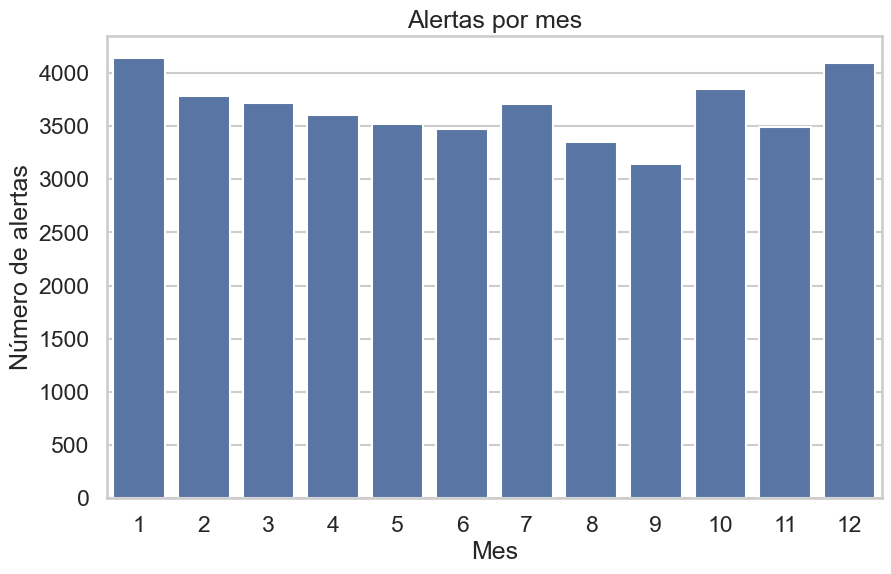

In [83]:
df_alertas["month"] = df_alertas["timestamp_start"].dt.month

monthly = df_alertas.groupby("month").size()

plt.figure(figsize=(10,6))
sns.barplot(x=monthly.index, y=monthly.values)
plt.title("Alertas por mes")
plt.xlabel("Mes")
plt.ylabel("Número de alertas")
plt.show()

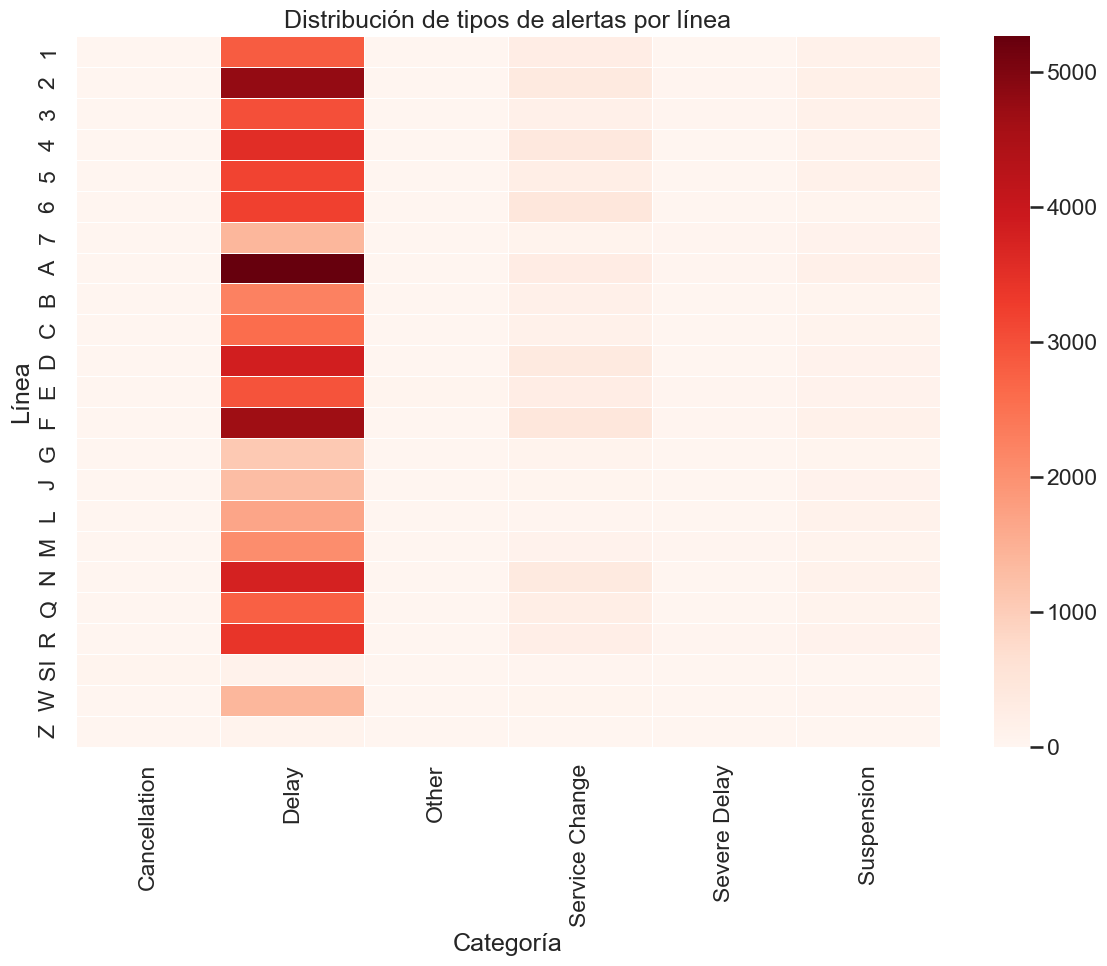

In [85]:
heatmap_data = (
    df_lines
    .groupby(["lines", "category"])
    .size()
    .unstack()
    .fillna(0)
)

plt.figure(figsize=(12,10))
sns.heatmap(heatmap_data, cmap="Reds", linewidths=0.5)
plt.title("Distribución de tipos de alertas por línea")
plt.xlabel("Categoría")
plt.ylabel("Línea")
plt.tight_layout()
plt.show()

## Esto hay que ver si es viable

In [ ]:
NYC_LOCATIONS = [

    # =========================
    # GRANDES HUBS
    # =========================
    "Grand Central",
    "Times Sq",
    "Times Square",
    "Atlantic Av",
    "Atlantic Avenue",
    "Atlantic Terminal",
    "Brooklyn Bridge",
    "Brooklyn Bridge-City Hall",
    "Astor Place",
    "Union Sq",
    "Union Square",
    "Herald Sq",
    "Herald Square",
    "Jackson Heights",
    "Jackson Heights-Roosevelt Av",
    "Queens Plaza",
    "Forest Hills",
    "Forest Hills-71 Av",
    "Coney Island",
    "Coney Island-Stillwell Av",
    "Howard Beach",
    "Howard Beach-JFK Airport",
    "Jamaica Center",
    "Jamaica Center-Parsons/Archer",
    "Far Rockaway",

    # =========================
    # MANHATTAN
    # =========================
    "Bowery",
    "Spring St",
    "Lexington Av",
    "Park Place",
    "Fulton St",
    "Grand St",
    "Canal St",
    "Wall St",
    "14 St",
    "23 St",
    "28 St",
    "34 St",
    "34 St-Herald Sq",
    "42 St",
    "50 St",
    "59 St",
    "72 St",
    "86 St",
    "96 St",
    "125 St",
    "Columbus Circle",
    "59 St-Columbus Circle",
    "South Ferry",

    # =========================
    # BROOKLYN
    # =========================
    "Kings Hwy",
    "Church Av",
    "Van Siclen Av",
    "Mets",
    "Brook Av",
    "Bay Ridge",
    "Bay Parkway",
    "New Lots Av",
    "Utica Av",
    "Flatbush Av",
    "Bedford Av",
    "Jay St",
    "Jay St-MetroTech",
    "Dekalb Av",
    "Myrtle Av",
    "Prospect Park",
    "Brighton Beach",
    "Sheepshead Bay",
    "Borough Hall",

    # =========================
    # QUEENS
    # =========================
    "Queensboro Plaza",
    "Jamaica",
    "Woodside",
    "Elmhurst Av",
    "Flushing",
    "Main St",
    "Roosevelt Av",
    "Kew Gardens",
    "Rockaway Blvd",
    "Ozone Park",
    "Aqueduct Racetrack",

    # =========================
    # BRONX
    # =========================
    "Bronx Park East",
    "Westchester Sq",
    "Morrison Av",
    "Pelham Bay Park",
    "Fordham Rd",
    "Yankee Stadium",
    "161 St-Yankee Stadium",
    "Gun Hill Rd",
    "Parkchester",

    # =========================
    # INFRAESTRUCTURA
    # =========================
    "South Channel Bridge",
    "Verrazzano Bridge",
    "Manhattan Bridge",
    "Williamsburg Bridge",
    "Queensboro Bridge",
    "RFK Bridge",
    "Hugh L. Carey Tunnel",
    "Lincoln Tunnel",
    "Holland Tunnel",

    # =========================
    # GENÉRICOS QUE APARECEN MUCHO
    # =========================
    "Bay",
    
]
import pandas as pd

NYC_LOCATIONS = sorted(NYC_LOCATIONS, key=len, reverse=True)

def extract_location(text: str) -> str:
    if pd.isna(text):
        return "Multiple/System-wide"

    text_lower = text.lower()

    for location in NYC_LOCATIONS:
        if location.lower() in text_lower:
            return location

    return "Multiple/System-wide"

df_grouped["location"] = df_grouped["header"].apply(extract_location)
df_grouped